In [109]:
import spike.spike_analysis.spike_collection as spike_collection
import spike.spike_analysis.spike_recording as sr
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.normalization as norm
import spike.spike_analysis.single_cell as single_cell
import behavior.behavioral_epoch_tools as betools
from spike.spike_analysis.spike_collection import SpikeCollection
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import behavior.boris_extraction as boris
import matplotlib.pyplot as plt
import pickle
import re
import seaborn as sns

# Set global seaborn style
sns.set_context("notebook", font_scale=1.9)

# Define color palette for Day 0 (Teal) and Day 7 (Magenta)
COLOR_DAY0 = '#53A1A9'  # Teal
COLOR_DAY7 = '#A95376'  # Magenta

In [110]:
import importlib
importlib.reload(sr)
importlib.reload(single_cell)

<module 'spike.spike_analysis.single_cell' from 'c:\\Users\\thoma\\Code\\ResearchCode\\rehouse\\diff_fam_social_memory_ephys\\spike\\spike_analysis\\single_cell.py'>

In [111]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [112]:
json_path = r"C:\Users\thoma\Code\ResearchCode\rehouse\diff_fam_social_memory_ephys\thomas-social-memory\data\spike_collection.json"
sc = SpikeCollection.load_collection(json_path)

In [113]:
epoch_bins = {}

condition_order = {
    # --- Subject 22 ---
    ("22", "d0"): "OM",
    ("22", "d7"): "MO",

    # --- Subject 23 ---
    ("23", "d0"): "MO",
    ("23", "d7"): "OM",

    # --- Subject 31 ---
    ("31", "d0"): "OM",
    ("31", "d7"): "MO",

    # --- Subject 32 ---
    ("32", "d0"): "MO",
    ("32", "d7"): "OM",

    # --- Subject 41 ---
    ("41", "d0"): "OM",
    ("41", "d7"): "MO",

    # --- Subject 44 ---
    ("44", "d0"): "MO",
    ("44", "d7"): "OM",
}


In [114]:
# ============================================================================
# FILTER RECORDINGS: Keep only subjects with BOTH d0 AND d7
# ============================================================================
print("="*80)
print("FILTERING RECORDINGS TO ENSURE PAIRED d0/d7 DATA")
print("="*80)

# Extract subject IDs and days from all recordings
subjects_by_day = {'d0': set(), 'd7': set()}

for rec in sc.recordings:
    rec_name = rec.name
    # Extract subject number (e.g., "22" from "22_rehouse_d0_merged.rec")
    subject_match = re.match(r'(\d+)_', rec_name)
    if subject_match:
        subject_id = subject_match.group(1)
        
        # Determine day
        if '_d0_' in rec_name or rec_name.endswith('_d0.rec'):
            subjects_by_day['d0'].add(subject_id)
        elif '_d7_' in rec_name or rec_name.endswith('_d7.rec'):
            subjects_by_day['d7'].add(subject_id)

print(f"\nSubjects with d0 recordings: {sorted(subjects_by_day['d0'])}")
print(f"Subjects with d7 recordings: {sorted(subjects_by_day['d7'])}")

# Find subjects that have BOTH d0 and d7
subjects_with_both = subjects_by_day['d0'] & subjects_by_day['d7']
subjects_missing_d0 = subjects_by_day['d7'] - subjects_by_day['d0']
subjects_missing_d7 = subjects_by_day['d0'] - subjects_by_day['d7']

print(f"\n✓ Subjects with BOTH d0 and d7: {sorted(subjects_with_both)}")
if subjects_missing_d0:
    print(f"⚠️ Subjects missing d0 (will be EXCLUDED): {sorted(subjects_missing_d0)}")
if subjects_missing_d7:
    print(f"⚠️ Subjects missing d7 (will be EXCLUDED): {sorted(subjects_missing_d7)}")

# Filter recordings to keep only those from subjects with both days
original_count = len(sc.recordings)
filtered_recordings = []
excluded_recordings = []

for rec in sc.recordings:
    rec_name = rec.name
    subject_match = re.match(r'(\d+)_', rec_name)
    if subject_match:
        subject_id = subject_match.group(1)
        if subject_id in subjects_with_both:
            filtered_recordings.append(rec)
        else:
            excluded_recordings.append(rec_name)
    else:
        # Keep recordings without clear subject ID pattern (shouldn't happen)
        filtered_recordings.append(rec)

# Update the SpikeCollection with filtered recordings
sc.recordings = filtered_recordings

if excluded_recordings:
    print(f"\nExcluded recordings:")
    for rec_name in excluded_recordings:
        print(f"  - {rec_name}")

print(f"\n✓ Analysis will proceed with {len(subjects_with_both)} subjects (paired d0/d7)")
print("="*80)

FILTERING RECORDINGS TO ENSURE PAIRED d0/d7 DATA

Subjects with d0 recordings: ['22', '32', '41', '44']
Subjects with d7 recordings: ['22', '31', '32', '41', '44']

✓ Subjects with BOTH d0 and d7: ['22', '32', '41', '44']
⚠️ Subjects missing d0 (will be EXCLUDED): ['31']

Excluded recordings:
  - 31_rehouse_d7_merged.rec

✓ Analysis will proceed with 4 subjects (paired d0/d7)


# Behavioral Bout Cleanup Pipeline

This analysis prepares cleaned behavioral event intervals for Wilcoxon signed-rank testing comparing D0 vs D7 neural responses.

## Workflow:
1. **Extract raw events** from each recording (facial sniff, anogenital sniff, chasing, fighting, object sniff)
2. **Clean bouts** using `threshold_bouts()` to:
   - Merge events separated by < min_iti (inter-bout interval)
   - Remove events shorter than min_bout duration
3. **Handle overlaps** using `overlapping_events()` to properly classify simultaneous behaviors
4. **Validate** with visualizations
5. **Prepare for Wilcoxon** analysis comparing D0 vs D7

In [115]:
# ============================================================================
# STEP 1: Extract Raw Behavioral Events
# ============================================================================
print("="*80)
print("STEP 1: EXTRACTING RAW BEHAVIORAL EVENTS")
print("="*80)

# Define which events to include/exclude
behavioral_events = [
    'facial sniffing',
    'anogenital sniffing', 
    'chasing',
    'fighting',
    'sniffing object'
]

exclude_events = ['mice back in', 'mice taken out']

# Store raw events organized by recording
raw_events_by_recording = {}

for rec in sc.recordings:
    rec_name = rec.name
    
    # Extract subject and day
    subject_match = re.match(r'(\d+)_', rec_name)
    if not subject_match:
        continue
    subject_id = subject_match.group(1)
    
    if '_d0_' in rec_name or rec_name.endswith('_d0.rec'):
        day = 'd0'
    elif '_d7_' in rec_name or rec_name.endswith('_d7.rec'):
        day = 'd7'
    else:
        continue
    
    print(f"\n{rec_name} (Subject {subject_id}, {day.upper()})")
    
    # Initialize storage for this recording
    raw_events_by_recording[rec_name] = {
        'subject': subject_id,
        'day': day,
        'events': {},
        'event_counts': {}
    }
    
    # Extract events from event_dict
    for event_name in rec.event_dict.keys():
        # Skip excluded events
        if event_name in exclude_events:
            continue
        
        # Get event windows (list of [start_ms, stop_ms])
        event_windows = rec.event_dict[event_name]
        
        if len(event_windows) > 0:
            # Convert to seconds for easier processing
            event_windows_sec = np.array([[start/1000, stop/1000] for start, stop in event_windows])
            
            raw_events_by_recording[rec_name]['events'][event_name] = event_windows_sec
            raw_events_by_recording[rec_name]['event_counts'][event_name] = len(event_windows_sec)
            
            # Calculate basic statistics
            durations = event_windows_sec[:, 1] - event_windows_sec[:, 0]
            mean_dur = np.mean(durations)
            
            print(f"  {event_name:20s}: {len(event_windows):4d} bouts, mean={mean_dur:.2f}s")

print("\n" + "="*80)
print(f"TOTAL RECORDINGS PROCESSED: {len(raw_events_by_recording)}")
print("="*80)

STEP 1: EXTRACTING RAW BEHAVIORAL EVENTS

22_rehouse_d0_merged.rec (Subject 22, D0)
  anogenital sniffing :   19 bouts, mean=2.16s
  facial sniffing     :   10 bouts, mean=0.68s
  fighting            :    4 bouts, mean=5.82s
  sniffing object     :   33 bouts, mean=1.88s

22_rehouse_d7_merged.rec (Subject 22, D7)
  anogenital sniffing :   11 bouts, mean=1.43s
  facial sniffing     :   13 bouts, mean=1.95s
  fighting            :    1 bouts, mean=0.81s
  sniffing object     :   21 bouts, mean=1.15s

32_rehouse_d0_merged.rec (Subject 32, D0)
  anogenital sniffing :    4 bouts, mean=1.57s
  sniffing object     :    6 bouts, mean=2.21s

32_rehouse_d7_merged.rec (Subject 32, D7)
  anogenital sniffing :   22 bouts, mean=2.37s
  facial sniffing     :   14 bouts, mean=1.79s
  sniffing object     :   32 bouts, mean=1.34s

41_rehouse_d0_merged.rec (Subject 41, D0)
  anogenital sniffing :   27 bouts, mean=3.30s
  facial sniffing     :   23 bouts, mean=1.49s
  sniffing object     :   44 bouts, mea

In [116]:
# ============================================================================
# STEP 2: Clean Bouts Using threshold_bouts
# ============================================================================
print("="*80)
print("STEP 2: CLEANING BOUTS (threshold_bouts)")
print("="*80)
print("\nParameters:")
print("  min_iti (inter-bout interval): 1.0 sec - merge events separated by < 1s")
print("  min_bout: 0.5 sec - remove bouts shorter than 0.5s")
print("="*80)

# Cleaning parameters
min_iti = 1.0   # Merge bouts separated by < 1 second
min_bout = 0.5  # Remove bouts < 0.5 seconds

# Store cleaned events
cleaned_events_by_recording = {}

for rec_name, rec_data in raw_events_by_recording.items():
    print(f"\n{rec_name}")
    
    cleaned_events_by_recording[rec_name] = {
        'subject': rec_data['subject'],
        'day': rec_data['day'],
        'events_raw': rec_data['events'].copy(),
        'events_cleaned': {},
        'cleaning_stats': {}
    }
    
    for event_name, event_windows in rec_data['events'].items():
        if len(event_windows) == 0:
            cleaned_events_by_recording[rec_name]['events_cleaned'][event_name] = event_windows
            continue
        
        # Apply threshold_bouts
        cleaned = betools.threshold_bouts(event_windows, min_iti=min_iti, min_bout=min_bout)
        
        # Store cleaned events
        cleaned_events_by_recording[rec_name]['events_cleaned'][event_name] = cleaned
        
        # Calculate statistics
        n_raw = len(event_windows)
        n_cleaned = len(cleaned)
        reduction_pct = ((n_raw - n_cleaned) / n_raw * 100) if n_raw > 0 else 0
        
        # Duration statistics
        raw_durations = event_windows[:, 1] - event_windows[:, 0]
        cleaned_durations = cleaned[:, 1] - cleaned[:, 0] if len(cleaned) > 0 else np.array([])
        
        raw_mean_dur = np.mean(raw_durations)
        cleaned_mean_dur = np.mean(cleaned_durations) if len(cleaned_durations) > 0 else 0
        
        cleaned_events_by_recording[rec_name]['cleaning_stats'][event_name] = {
            'n_raw': n_raw,
            'n_cleaned': n_cleaned,
            'reduction_pct': reduction_pct,
            'raw_mean_duration': raw_mean_dur,
            'cleaned_mean_duration': cleaned_mean_dur
        }
        
        print(f"  {event_name:20s}: {n_raw:4d} → {n_cleaned:4d} bouts ({reduction_pct:+.1f}%), "
              f"dur: {raw_mean_dur:.2f}s → {cleaned_mean_dur:.2f}s")

print("\n" + "="*80)
print("BOUT CLEANING COMPLETE")
print("="*80)

STEP 2: CLEANING BOUTS (threshold_bouts)

Parameters:
  min_iti (inter-bout interval): 1.0 sec - merge events separated by < 1s
  min_bout: 0.5 sec - remove bouts shorter than 0.5s

22_rehouse_d0_merged.rec
  anogenital sniffing :   19 →   17 bouts (+10.5%), dur: 2.16s → 2.39s
  facial sniffing     :   10 →    5 bouts (+50.0%), dur: 0.68s → 1.11s
  fighting            :    4 →    4 bouts (+0.0%), dur: 5.82s → 5.82s
  sniffing object     :   33 →   25 bouts (+24.2%), dur: 1.88s → 2.43s

22_rehouse_d7_merged.rec
  anogenital sniffing :   11 →   10 bouts (+9.1%), dur: 1.43s → 1.54s
  facial sniffing     :   13 →   12 bouts (+7.7%), dur: 1.95s → 2.07s
  fighting            :    1 →    1 bouts (+0.0%), dur: 0.81s → 0.81s
  sniffing object     :   21 →   16 bouts (+23.8%), dur: 1.15s → 1.48s

32_rehouse_d0_merged.rec
  anogenital sniffing :    4 →    3 bouts (+25.0%), dur: 1.57s → 2.02s
  sniffing object     :    6 →    6 bouts (+0.0%), dur: 2.21s → 2.21s

32_rehouse_d7_merged.rec
  anogenit

In [117]:
# ============================================================================
# STEP 3: Add Cleaned Events as New Attribute to Recordings
# ============================================================================
print("="*80)
print("STEP 3: ADDING CLEANED EVENTS TO SPIKE COLLECTION RECORDINGS")
print("="*80)
print("\nCreating 'event_dict_cleaned' attribute for each recording")
print("Original events remain in 'event_dict'")
print("="*80)

for rec in sc.recordings:
    rec_name = rec.name
    
    # Initialize cleaned event dict for this recording
    rec.event_dict_cleaned = {}
    
    if rec_name in cleaned_events_by_recording:
        cleaned_data = cleaned_events_by_recording[rec_name]['events_cleaned']
        
        print(f"\n{rec_name}:")
        
        for event_name, event_windows_sec in cleaned_data.items():
            if len(event_windows_sec) > 0:
                # Convert back to milliseconds to match original event_dict format
                event_windows_ms = [[start*1000, stop*1000] for start, stop in event_windows_sec]
                rec.event_dict_cleaned[event_name] = event_windows_ms
                
                # Compare with original
                original_count = len(rec.event_dict.get(event_name, []))
                cleaned_count = len(event_windows_ms)
                
                print(f"  {event_name:20s}: {original_count:3d} → {cleaned_count:3d} bouts")
            else:
                rec.event_dict_cleaned[event_name] = []
    else:
        print(f"\n{rec_name}: No cleaned events (may have been filtered)")

print("\n" + "="*80)
print("CLEANED EVENTS ADDED TO RECORDINGS")
print("="*80)
print("\nYou can now access:")
print("  rec.event_dict         → Original behavioral events")
print("  rec.event_dict_cleaned → Cleaned behavioral events (merged & thresholded)")
print("="*80)

STEP 3: ADDING CLEANED EVENTS TO SPIKE COLLECTION RECORDINGS

Creating 'event_dict_cleaned' attribute for each recording
Original events remain in 'event_dict'

22_rehouse_d0_merged.rec:
  anogenital sniffing :  19 →  17 bouts
  facial sniffing     :  10 →   5 bouts
  fighting            :   4 →   4 bouts
  sniffing object     :  33 →  25 bouts

22_rehouse_d7_merged.rec:
  anogenital sniffing :  11 →  10 bouts
  facial sniffing     :  13 →  12 bouts
  fighting            :   1 →   1 bouts
  sniffing object     :  21 →  16 bouts

32_rehouse_d0_merged.rec:
  anogenital sniffing :   4 →   3 bouts
  sniffing object     :   6 →   6 bouts

32_rehouse_d7_merged.rec:
  anogenital sniffing :  22 →  19 bouts
  facial sniffing     :  14 →  13 bouts
  sniffing object     :  32 →  25 bouts

41_rehouse_d0_merged.rec:
  anogenital sniffing :  27 →  25 bouts
  facial sniffing     :  23 →  20 bouts
  sniffing object     :  44 →  39 bouts

41_rehouse_d7_merged.rec:
  anogenital sniffing :   8 →   7 bout

In [118]:
# Verify the new attribute was added successfully
print("Verification: Checking a sample recording")
print("="*80)

sample_rec = sc.recordings[0]

# Show comparison for one event
if sample_rec.event_dict_cleaned:
    event_name = list(sample_rec.event_dict_cleaned.keys())[0]
    orig_count = len(sample_rec.event_dict.get(event_name, []))
    clean_count = len(sample_rec.event_dict_cleaned[event_name])
    
    print(f"\nExample - '{event_name}':")
    print(f"  Original: {orig_count} bouts")
    print(f"  Cleaned:  {clean_count} bouts")
    print("bouts")
    for i, bout in enumerate(sample_rec.event_dict[event_name]):
        print(f"    {i+1}. [{bout[0]:.1f}, {bout[1]:.1f}] (duration: {(bout[1]-bout[0])/1000:.2f}s)")
    print(f"\n  First 3 cleaned bouts (ms):")
    for i, bout in enumerate(sample_rec.event_dict_cleaned[event_name]):
        print(f"    {i+1}. [{bout[0]:.1f}, {bout[1]:.1f}] (duration: {(bout[1]-bout[0])/1000:.2f}s)")

print("\n" + "="*80)
print("✓ Both event dictionaries are now available on each recording!")

Verification: Checking a sample recording

Example - 'anogenital sniffing':
  Original: 19 bouts
  Cleaned:  17 bouts
bouts
    1. [1204874.9, 1208405.6] (duration: 3.53s)
    2. [1229127.6, 1231414.3] (duration: 2.29s)
    3. [1237304.2, 1237997.1] (duration: 0.69s)
    4. [1243540.6, 1245477.4] (duration: 1.94s)
    5. [1252826.0, 1254489.0] (duration: 1.66s)
    6. [1331474.1, 1333067.8] (duration: 1.59s)
    7. [1350114.0, 1354964.5] (duration: 4.85s)
    8. [1363349.1, 1363695.5] (duration: 0.35s)
    9. [1367298.8, 1367922.4] (duration: 0.62s)
    10. [1373743.1, 1376861.3] (duration: 3.12s)
    11. [1379840.9, 1382196.9] (duration: 2.36s)
    12. [1383859.9, 1386978.1] (duration: 3.12s)
    13. [1390997.1, 1392105.8] (duration: 1.11s)
    14. [1455301.5, 1457241.8] (duration: 1.94s)
    15. [1522793.3, 1525149.3] (duration: 2.36s)
    16. [1554460.5, 1558895.2] (duration: 4.43s)
    17. [1705173.8, 1705312.4] (duration: 0.14s)
    18. [1721734.9, 1724714.5] (duration: 2.98s)
   

In [119]:
# ============================================================================
# STEP 4: Run Wilcoxon Tests Using Cleaned Events
# ============================================================================
print("="*80)
print("STEP 4: WILCOXON SIGNED-RANK TESTS ON CLEANED EVENTS")
print("="*80)

# Parameters for Wilcoxon test
event_length = 5  # seconds - standardize all events to 5s
baseline_window = 5  # seconds - use 5s baseline before event
offset = 0  # no offset
exclude_offset = False

# Store all results
all_wilcoxon_results = []

print(f"\nTest Parameters:")
print(f"  Event length: {event_length}s")
print(f"  Baseline window: {baseline_window}s")
print(f"  Minimum bouts required: 6")
print("="*80)

for rec in sc.recordings:
    rec_name = rec.name
    
    # Extract subject and day
    subject_match = re.match(r'(\d+)_', rec_name)
    if not subject_match:
        continue
    subject_id = subject_match.group(1)
    
    if '_d0_' in rec_name or rec_name.endswith('_d0.rec') or '_d0_merged' in rec_name:
        day = 'd0'
    elif '_d7_' in rec_name or rec_name.endswith('_d7.rec') or '_d7_merged' in rec_name:
        day = 'd7'
    else:
        continue
    
    print(f"\n{rec_name} (Subject {subject_id}, {day.upper()})")
    
    # Get good units for this recording
    good_units = getattr(rec, "good_units", None)
    if good_units is None:
        if hasattr(rec, 'labels_dict'):
            good_units = [unit_id for unit_id, label in rec.labels_dict.items() if label == "good"]
        else:
            good_units = list(rec.unit_timestamps.keys())
    
    n_good_units = len([u for u in good_units if u in rec.unit_timestamps and len(rec.unit_timestamps[u]) > 0])
    
    # Process each cleaned event type
    if hasattr(rec, 'event_dict_cleaned') and rec.event_dict_cleaned:
        for event_name, event_windows_ms in rec.event_dict_cleaned.items():
            n_bouts = len(event_windows_ms)
            
            if n_bouts < 6:
                print(f"  {event_name:25s}: Skipped ({n_bouts} bouts < 6 minimum)")
                continue
            
            # Temporarily set event_dict to use cleaned events
            original_events = rec.event_dict[event_name] if event_name in rec.event_dict else None
            rec.event_dict[event_name] = event_windows_ms
            
            try:
                # Run Wilcoxon test using single_cell module
                wilcox_df = single_cell.wilcoxon_rec(
                    rec, 
                    event_name, 
                    event_length, 
                    baseline_window, 
                    offset, 
                    exclude_offset
                )
                
                if wilcox_df is not None:
                    # Count significant units
                    n_sig = len(wilcox_df[wilcox_df['p value'] < 0.05])
                    n_increase = len(wilcox_df[(wilcox_df['p value'] < 0.05) & (wilcox_df['event1 vs event2'] == 'increases')])
                    n_decrease = len(wilcox_df[(wilcox_df['p value'] < 0.05) & (wilcox_df['event1 vs event2'] == 'decreases')])
                    n_total = len(wilcox_df)
                    
                    print(f"  {event_name:25s}: {n_total} units, {n_sig:3d} sig ({100*n_sig/n_total:5.1f}%) [↑{n_increase}, ↓{n_decrease}]")
                    
                    # Store results
                    all_wilcoxon_results.append({
                        'recording': rec_name,
                        'subject': subject_id,
                        'day': day,
                        'event': event_name,
                        'n_bouts': n_bouts,
                        'n_units_total': n_total,
                        'n_sig': n_sig,
                        'n_increase': n_increase,
                        'n_decrease': n_decrease,
                        'pct_sig': 100 * n_sig / n_total if n_total > 0 else 0,
                        'wilcox_df': wilcox_df
                    })
                    
            except Exception as e:
                print(f"  {event_name:25s}: Error - {str(e)}")
            
            finally:
                # Restore original events
                if original_events is not None:
                    rec.event_dict[event_name] = original_events
    else:
        print("  No cleaned events available")

print("\n" + "="*80)
print(f"WILCOXON TESTS COMPLETE: {len(all_wilcoxon_results)} event×recording combinations analyzed")
print("="*80)

STEP 4: WILCOXON SIGNED-RANK TESTS ON CLEANED EVENTS

Test Parameters:
  Event length: 5s
  Baseline window: 5s
  Minimum bouts required: 6

22_rehouse_d0_merged.rec (Subject 22, D0)
  anogenital sniffing      : Error - 'SpikeRecording' object has no attribute 'unit_firing_rates'
  facial sniffing          : Skipped (5 bouts < 6 minimum)
  fighting                 : Skipped (4 bouts < 6 minimum)
  sniffing object          : Error - 'SpikeRecording' object has no attribute 'unit_firing_rates'

22_rehouse_d7_merged.rec (Subject 22, D7)
  anogenital sniffing      : Error - 'SpikeRecording' object has no attribute 'unit_firing_rates'
  facial sniffing          : Error - 'SpikeRecording' object has no attribute 'unit_firing_rates'
  fighting                 : Skipped (1 bouts < 6 minimum)
  sniffing object          : Error - 'SpikeRecording' object has no attribute 'unit_firing_rates'

32_rehouse_d0_merged.rec (Subject 32, D0)
  anogenital sniffing      : Skipped (3 bouts < 6 minimum)
  sni

In [120]:
# Check if we have results
print(f"Number of results: {len(all_wilcoxon_results)}")

if len(all_wilcoxon_results) > 0:
    # Convert results to DataFrame for easier analysis
    wilcoxon_df = pd.DataFrame(all_wilcoxon_results)

    print("\nSummary of Wilcoxon Results:")
    print("="*80)
    print(wilcoxon_df[['recording', 'day', 'event', 'n_bouts', 'n_units_total', 'n_sig', 'pct_sig']])
    print("="*80)
else:
    print("\n⚠️ No Wilcoxon results found!")
    print("This might be because:")
    print("  1. All events have < 6 bouts")
    print("  2. There was an error in the wilcoxon test")
    print("  3. No good units available")
    
    # Debug: Check a sample recording
    sample_rec = sc.recordings[0]
    print(f"\nDebug info for {sample_rec.name}:")
    print(f"  Has event_dict_cleaned: {hasattr(sample_rec, 'event_dict_cleaned')}")
    if hasattr(sample_rec, 'event_dict_cleaned'):
        print(f"  Cleaned events: {list(sample_rec.event_dict_cleaned.keys())}")
        for evt, windows in sample_rec.event_dict_cleaned.items():
            print(f"    {evt}: {len(windows)} bouts")

Number of results: 0

⚠️ No Wilcoxon results found!
This might be because:
  1. All events have < 6 bouts
  2. There was an error in the wilcoxon test
  3. No good units available

Debug info for 22_rehouse_d0_merged.rec:
  Has event_dict_cleaned: True
  Cleaned events: ['anogenital sniffing', 'facial sniffing', 'fighting', 'sniffing object']
    anogenital sniffing: 17 bouts
    facial sniffing: 5 bouts
    fighting: 4 bouts
    sniffing object: 25 bouts


In [121]:
# ============================================================================
# CUSTOM WILCOXON IMPLEMENTATION (bypassing timebin requirement)
# ============================================================================
from scipy.stats import wilcoxon as scipy_wilcoxon

def custom_wilcoxon_test(recording, event_windows_ms, event_name, baseline_window_sec=5, min_bouts=6):
    """
    Custom Wilcoxon test that works directly with event windows without requiring timebin attribute.
    
    Parameters:
    -----------
    recording : SpikeRecording
    event_windows_ms : list of [start_ms, stop_ms]
    event_name : str
    baseline_window_sec : float (default 5)
    min_bouts : int (default 6)
    
    Returns:
    --------
    results_df : DataFrame with Wilcoxon results per unit
    """
    sr = recording.sampling_rate
    
    # Get good units
    good_units = getattr(recording, "good_units", None)
    if good_units is None:
        if hasattr(recording, 'labels_dict'):
            good_units = [unit_id for unit_id, label in recording.labels_dict.items() if label == "good"]
        else:
            good_units = list(recording.unit_timestamps.keys())
    
    # Filter to units with data
    rec_gunits = {unit: recording.unit_timestamps[unit] for unit in good_units 
                  if unit in recording.unit_timestamps and len(recording.unit_timestamps[unit]) > 0}
    
    if len(event_windows_ms) < min_bouts:
        return None
    
    results = []
    
    for unit, ts in rec_gunits.items():
        # Convert spike times to seconds
        spike_times_sec = ts / sr
        
        # Calculate firing rates for each event bout
        event_rates = []
        baseline_rates = []
        
        for start_ms, stop_ms in event_windows_ms:
            start_sec = start_ms / 1000
            stop_sec = stop_ms / 1000
            duration = stop_sec - start_sec
            
            if duration <= 0:
                continue
            
            # Event firing rate
            n_spikes_event = np.sum((spike_times_sec >= start_sec) & (spike_times_sec < stop_sec))
            rate_event = n_spikes_event / duration
            event_rates.append(rate_event)
            
            # Baseline firing rate (before event)
            baseline_start = start_sec - baseline_window_sec
            baseline_stop = start_sec
            
            if baseline_start >= 0:  # Make sure baseline is within recording
                n_spikes_baseline = np.sum((spike_times_sec >= baseline_start) & (spike_times_sec < baseline_stop))
                rate_baseline = n_spikes_baseline / baseline_window_sec
                baseline_rates.append(rate_baseline)
            else:
                # Skip this bout if baseline would be before recording start
                event_rates.pop()
                continue
        
        # Perform Wilcoxon signed-rank test if we have enough paired samples
        if len(event_rates) >= min_bouts and len(baseline_rates) >= min_bouts:
            try:
                # Calculate differences
                differences = np.array(event_rates) - np.array(baseline_rates)
                non_zero_diffs = differences[differences != 0]
                
                if len(non_zero_diffs) >= 3:  # Need at least 3 non-zero differences
                    stat, p_value = scipy_wilcoxon(non_zero_diffs)
                    
                    # Determine direction
                    mean_event = np.mean(event_rates)
                    mean_baseline = np.mean(baseline_rates)
                    
                    if p_value < 0.05:
                        direction = "increases" if mean_event > mean_baseline else "decreases"
                    else:
                        direction = "not significant"
                    
                    results.append({
                        'unit': unit,
                        'n_bouts': len(event_rates),
                        'mean_event_rate': mean_event,
                        'mean_baseline_rate': mean_baseline,
                        'Wilcoxon Stat': stat,
                        'p value': p_value,
                        'event1 vs event2': direction
                    })
            except Exception as e:
                # Skip units where wilcoxon fails
                pass
    
    if len(results) > 0:
        return pd.DataFrame(results)
    else:
        return None

print("✓ Custom Wilcoxon function defined")

✓ Custom Wilcoxon function defined


In [122]:
# ============================================================================
# RUN CUSTOM WILCOXON TESTS ON ALL RECORDINGS
# ============================================================================
print("="*80)
print("RUNNING CUSTOM WILCOXON TESTS ON CLEANED EVENTS")
print("="*80)

baseline_window = 5  # seconds
min_bouts = 6

# Clear previous results
all_wilcoxon_results = []

for rec in sc.recordings:
    rec_name = rec.name
    
    # Extract subject and day
    subject_match = re.match(r'(\d+)_', rec_name)
    if not subject_match:
        continue
    subject_id = subject_match.group(1)
    
    if '_d0_' in rec_name or rec_name.endswith('_d0.rec') or '_d0_merged' in rec_name:
        day = 'd0'
    elif '_d7_' in rec_name or rec_name.endswith('_d7.rec') or '_d7_merged' in rec_name:
        day = 'd7'
    else:
        continue
    
    print(f"\n{rec_name} (Subject {subject_id}, {day.upper()})")
    
    # Process each cleaned event type
    if hasattr(rec, 'event_dict_cleaned') and rec.event_dict_cleaned:
        for event_name, event_windows_ms in rec.event_dict_cleaned.items():
            n_bouts = len(event_windows_ms)
            
            if n_bouts < min_bouts:
                print(f"  {event_name:25s}: Skipped ({n_bouts} bouts < {min_bouts} minimum)")
                continue
            
            # Run custom Wilcoxon test
            wilcox_df = custom_wilcoxon_test(rec, event_windows_ms, event_name, baseline_window, min_bouts)
            
            if wilcox_df is not None and len(wilcox_df) > 0:
                # Count significant units
                n_sig = len(wilcox_df[wilcox_df['p value'] < 0.05])
                n_increase = len(wilcox_df[(wilcox_df['p value'] < 0.05) & (wilcox_df['event1 vs event2'] == 'increases')])
                n_decrease = len(wilcox_df[(wilcox_df['p value'] < 0.05) & (wilcox_df['event1 vs event2'] == 'decreases')])
                n_total = len(wilcox_df)
                
                print(f"  {event_name:25s}: {n_total:3d} units, {n_sig:3d} sig ({100*n_sig/n_total:5.1f}%) [↑{n_increase}, ↓{n_decrease}]")
                
                # Store results
                all_wilcoxon_results.append({
                    'recording': rec_name,
                    'subject': subject_id,
                    'day': day,
                    'event': event_name,
                    'n_bouts': n_bouts,
                    'n_units_total': n_total,
                    'n_sig': n_sig,
                    'n_increase': n_increase,
                    'n_decrease': n_decrease,
                    'pct_sig': 100 * n_sig / n_total if n_total > 0 else 0,
                    'wilcox_df': wilcox_df
                })
            else:
                print(f"  {event_name:25s}: No valid results")

print("\n" + "="*80)
print(f"✓ ANALYSIS COMPLETE: {len(all_wilcoxon_results)} event×recording combinations")
print("="*80)

RUNNING CUSTOM WILCOXON TESTS ON CLEANED EVENTS

22_rehouse_d0_merged.rec (Subject 22, D0)
  anogenital sniffing      :  14 units,   6 sig ( 42.9%) [↑0, ↓6]
  facial sniffing          : Skipped (5 bouts < 6 minimum)
  fighting                 : Skipped (4 bouts < 6 minimum)
  sniffing object          :  14 units,   6 sig ( 42.9%) [↑2, ↓4]

22_rehouse_d7_merged.rec (Subject 22, D7)
  anogenital sniffing      :   9 units,   3 sig ( 33.3%) [↑2, ↓1]
  facial sniffing          :   9 units,   1 sig ( 11.1%) [↑1, ↓0]
  fighting                 : Skipped (1 bouts < 6 minimum)
  sniffing object          :   9 units,   1 sig ( 11.1%) [↑0, ↓1]

32_rehouse_d0_merged.rec (Subject 32, D0)
  anogenital sniffing      : Skipped (3 bouts < 6 minimum)
  sniffing object          :   8 units,   1 sig ( 12.5%) [↑0, ↓1]

32_rehouse_d7_merged.rec (Subject 32, D7)
  anogenital sniffing      :   4 units,   1 sig ( 25.0%) [↑0, ↓1]
  facial sniffing          :   4 units,   0 sig (  0.0%) [↑0, ↓0]
  sniffing objec

In [123]:
# Create summary DataFrame
if len(all_wilcoxon_results) > 0:
    wilcoxon_df = pd.DataFrame(all_wilcoxon_results)
    
    print("\n" + "="*80)
    print("WILCOXON RESULTS SUMMARY")
    print("="*80)
    display(wilcoxon_df[['recording', 'subject', 'day', 'event', 'n_bouts', 'n_units_total', 'n_sig', 'n_increase', 'n_decrease', 'pct_sig']])
else:
    print("\n⚠️ No results to display")


WILCOXON RESULTS SUMMARY


,recording,subject,day,event,n_bouts,n_units_total,n_sig,n_increase,n_decrease,pct_sig
0,22_rehouse_d0_merged.rec,22,d0,anogenital sniffing,17,14,6,0,6,42.857143
1,22_rehouse_d0_merged.rec,22,d0,sniffing object,25,14,6,2,4,42.857143
2,22_rehouse_d7_merged.rec,22,d7,anogenital sniffing,10,9,3,2,1,33.333333
3,22_rehouse_d7_merged.rec,22,d7,facial sniffing,12,9,1,1,0,11.111111
4,22_rehouse_d7_merged.rec,22,d7,sniffing object,16,9,1,0,1,11.111111
5,32_rehouse_d0_merged.rec,32,d0,sniffing object,6,8,1,0,1,12.500000
6,32_rehouse_d7_merged.rec,32,d7,anogenital sniffing,19,4,1,0,1,25.000000
7,32_rehouse_d7_merged.rec,32,d7,facial sniffing,13,4,0,0,0,0.000000
8,32_rehouse_d7_merged.rec,32,d7,sniffing object,25,4,0,0,0,0.000000
9,41_rehouse_d0_merged.rec,41,d0,anogenital sniffing,25,26,4,2,2,15.384615


# D0 vs D7 Comparison Plots

Now we'll compare the number of significant neurons for each event type between D0 and D7.

In [124]:
# ============================================================================
# PLOT: Significant Neuron Counts - D0 vs D7
# ============================================================================

# Group by event and day to aggregate across subjects
event_day_summary = wilcoxon_df.groupby(['event', 'day']).agg({
    'n_sig': 'sum',
    'n_units_total': 'sum',
    'recording': 'count'  # Number of recordings
}).reset_index()

event_day_summary['pct_sig'] = 100 * event_day_summary['n_sig'] / event_day_summary['n_units_total']

print("="*80)
print("AGGREGATED SUMMARY BY EVENT AND DAY")
print("="*80)
display(event_day_summary)

# Get unique events that appear in both D0 and D7
events_d0 = set(event_day_summary[event_day_summary['day'] == 'd0']['event'])
events_d7 = set(event_day_summary[event_day_summary['day'] == 'd7']['event'])
common_events = sorted(events_d0 & events_d7)

print(f"\nEvents present in both D0 and D7: {common_events}")

AGGREGATED SUMMARY BY EVENT AND DAY


,event,day,n_sig,n_units_total,recording,pct_sig
0,anogenital sniffing,d0,10,44,3,22.727273
1,anogenital sniffing,d7,8,48,4,16.666667
2,facial sniffing,d0,7,29,2,24.137931
3,facial sniffing,d7,3,49,4,6.122449
4,sniffing object,d0,12,52,4,23.076923
5,sniffing object,d7,12,49,4,24.489796



Events present in both D0 and D7: ['anogenital sniffing', 'facial sniffing', 'sniffing object']


SOCIAL BEHAVIORS


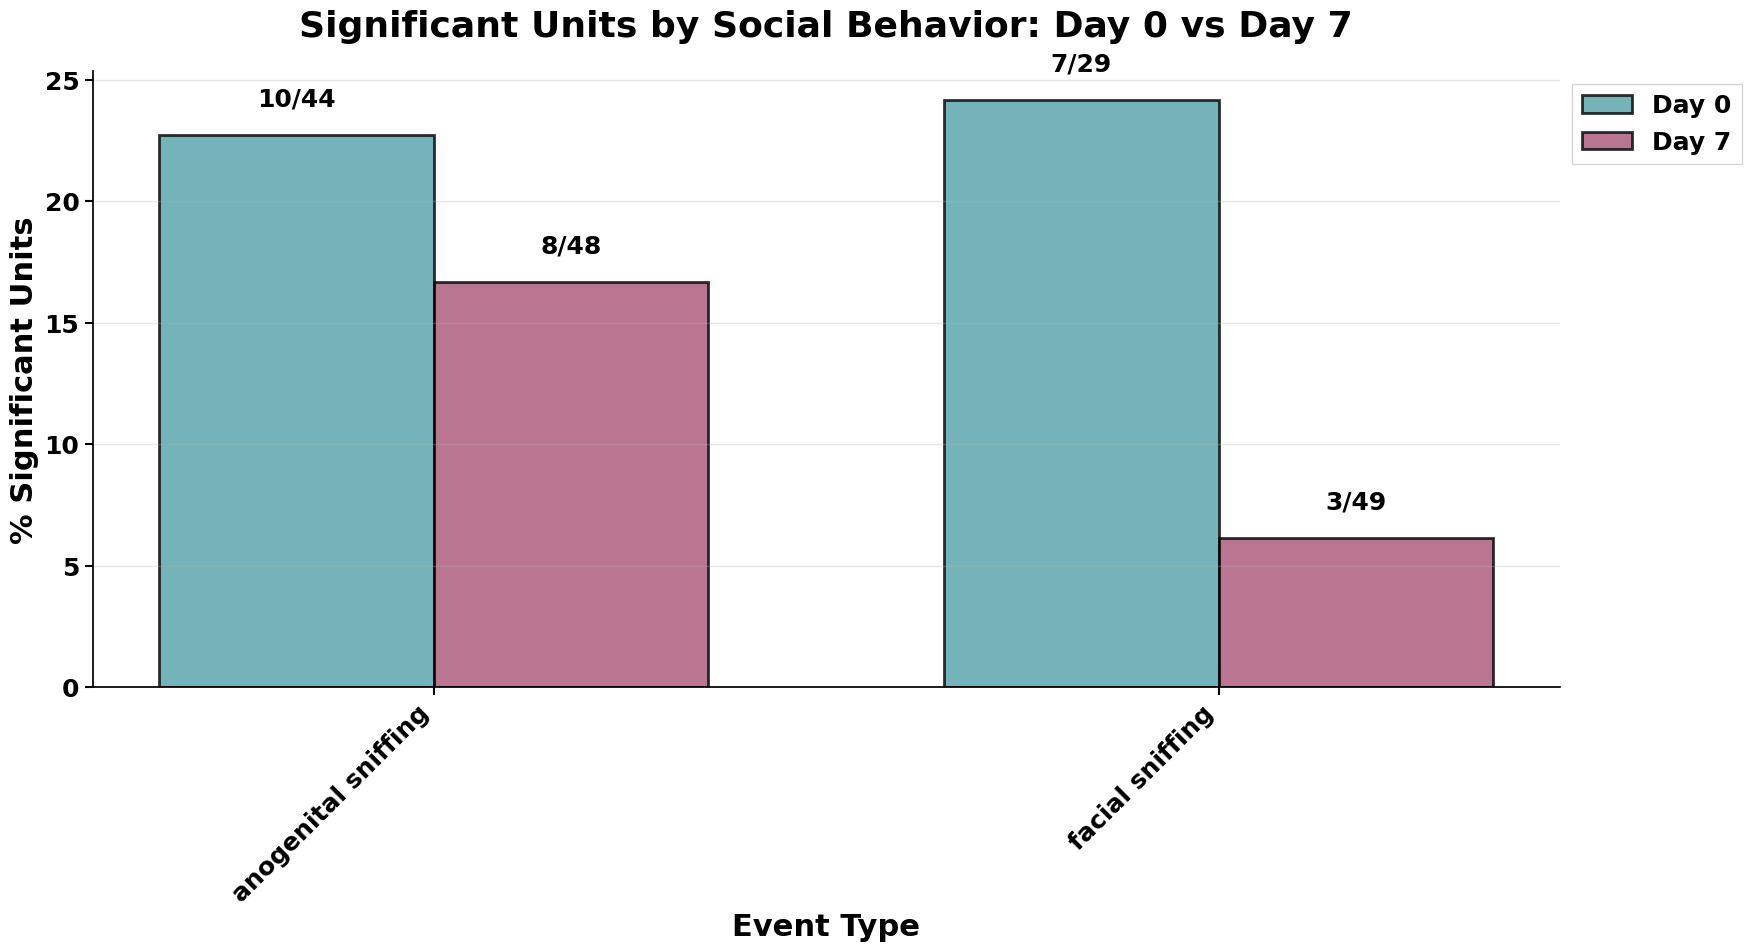


OBJECT BEHAVIOR


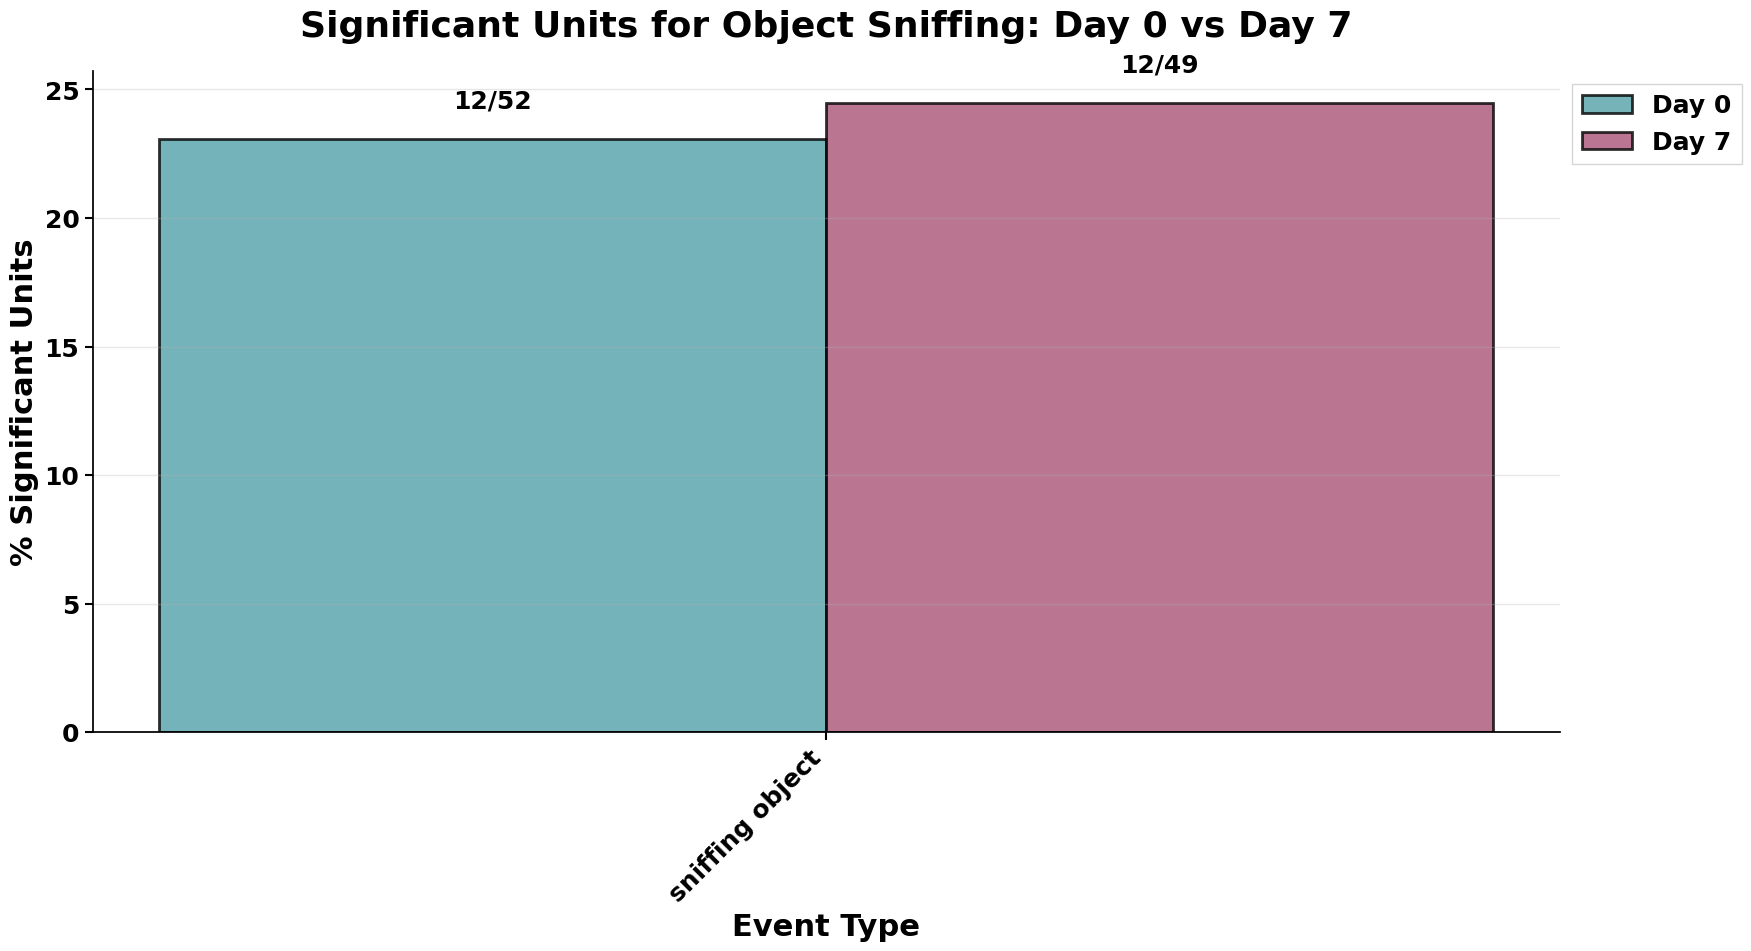


DETAILED SUMMARY: UNITS TESTED AND SIGNIFICANT UNITS BY EVENT TYPE AND DAY
Event                               Day   Total Units     Sig Units       % Sig     
----------------------------------------------------------------------------------------------------
anogenital sniffing                 d0    44              10                22.7%
anogenital sniffing                 d7    48              8                 16.7%

facial sniffing                     d0    29              7                 24.1%
facial sniffing                     d7    49              3                  6.1%

sniffing object                     d0    52              12                23.1%
sniffing object                     d7    49              12                24.5%



In [125]:
# ============================================================================
# PLOT 1: Bar Plot - Significant Neuron Counts by Event (D0 vs D7)
# ============================================================================

# Calculate statistics for d0
sig_by_event_d0 = wilcoxon_df[wilcoxon_df['day'] == 'd0'].groupby('event')['n_sig'].sum()
total_by_event_d0 = wilcoxon_df[wilcoxon_df['day'] == 'd0'].groupby('event')['n_units_total'].sum()

# Calculate statistics for d7
sig_by_event_d7 = wilcoxon_df[wilcoxon_df['day'] == 'd7'].groupby('event')['n_sig'].sum()
total_by_event_d7 = wilcoxon_df[wilcoxon_df['day'] == 'd7'].groupby('event')['n_units_total'].sum()

# Get all unique events from both days
all_events = sorted(set(total_by_event_d0.index) | set(total_by_event_d7.index))

# Separate social behaviors from object sniffing
social_events = [e for e in all_events if e != 'sniffing object']
object_events = [e for e in all_events if e == 'sniffing object']

# Function to create plot for a set of events
def create_event_plot(events_to_plot, title_suffix):
    if not events_to_plot:
        return
    
    # Prepare data for plotting
    d0_sig_counts = [sig_by_event_d0.get(event, 0) for event in events_to_plot]
    d0_total_counts = [total_by_event_d0.get(event, 0) for event in events_to_plot]
    d7_sig_counts = [sig_by_event_d7.get(event, 0) for event in events_to_plot]
    d7_total_counts = [total_by_event_d7.get(event, 0) for event in events_to_plot]
    
    # Create side-by-side bar plot with new styling
    fig, ax = plt.subplots(figsize=(18, 10))
    
    # Transparent background
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    
    x = np.arange(len(events_to_plot))
    
    # Adjust bar width based on number of events (narrower for single event)
    if len(events_to_plot) == 1:
        width = 0.12  # Much narrower for single event (about 1/3 of default)
    else:
        width = 0.35  # Default width for multiple events
    
    # Calculate percentages
    d0_percent = [(sig/total*100 if total > 0 else 0) for sig, total in zip(d0_sig_counts, d0_total_counts)]
    d7_percent = [(sig/total*100 if total > 0 else 0) for sig, total in zip(d7_sig_counts, d7_total_counts)]
    
    # Create bars with new colors
    bars1 = ax.bar(x - width/2, d0_percent, width, label='Day 0', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY0)
    bars2 = ax.bar(x + width/2, d7_percent, width, label='Day 7', alpha=0.8, 
                   edgecolor='black', linewidth=2, color=COLOR_DAY7)
    
    # Font sizes according to style guide - all text bold
    ax.set_ylabel('% Significant Units', fontsize=22, fontweight='bold')
    ax.set_xlabel('Event Type', fontsize=22, fontweight='bold')
    ax.set_title(f'{title_suffix}: Day 0 vs Day 7', fontsize=26, fontweight='bold', pad=25)
    
    # Clean up x-axis labels (remove parentheses and make them more readable)
    clean_event_labels = []
    for event in events_to_plot:
        # Remove any parentheses in the event names
        clean_label = event.replace('(', '').replace(')', '')
        clean_event_labels.append(clean_label)
    
    ax.set_xticks(x)
    ax.set_xticklabels(clean_event_labels, rotation=45, ha='right', fontsize=18, fontweight='bold')
    ax.tick_params(axis='y', labelsize=18, width=1.5, length=6)
    ax.tick_params(axis='x', width=1.5, length=6)
    
    # Make y-axis tick labels bold
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    
    # Legend positioned outside plot area with bold text
    legend = ax.legend(fontsize=18, frameon=True, fancybox=False, 
                      loc='upper left', bbox_to_anchor=(1.0, 1.0))
    for text in legend.get_texts():
        text.set_fontweight('bold')
    
    # Apply seaborn despine and grid styling
    sns.despine(ax=ax)
    ax.grid(axis='y', alpha=0.3, linewidth=1)
    
    # Add count labels on bars
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        # d0 labels
        if d0_total_counts[i] > 0:
            height1 = bar1.get_height()
            ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 1,
                    f'{d0_sig_counts[i]}/{d0_total_counts[i]}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')
        
        # d7 labels
        if d7_total_counts[i] > 0:
            height2 = bar2.get_height()
            ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 1,
                    f'{d7_sig_counts[i]}/{d7_total_counts[i]}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Create plot for social behaviors
print("="*100)
print("SOCIAL BEHAVIORS")
print("="*100)
create_event_plot(social_events, 'Significant Units by Social Behavior')

# Create plot for object sniffing
print("\n" + "="*100)
print("OBJECT BEHAVIOR")
print("="*100)
create_event_plot(object_events, 'Significant Units for Object Sniffing')

# Print detailed summary table
print("\n" + "="*100)
print("DETAILED SUMMARY: UNITS TESTED AND SIGNIFICANT UNITS BY EVENT TYPE AND DAY")
print("="*100)
print(f"{'Event':<35} {'Day':<5} {'Total Units':<15} {'Sig Units':<15} {'% Sig':<10}")
print("-"*100)

for event in all_events:
    # d0 stats
    d0_total = total_by_event_d0.get(event, 0)
    d0_sig = sig_by_event_d0.get(event, 0)
    d0_pct = (d0_sig / d0_total * 100) if d0_total > 0 else 0
    print(f"{event:<35} {'d0':<5} {d0_total:<15} {d0_sig:<15} {d0_pct:>6.1f}%")
    
    # d7 stats
    d7_total = total_by_event_d7.get(event, 0)
    d7_sig = sig_by_event_d7.get(event, 0)
    d7_pct = (d7_sig / d7_total * 100) if d7_total > 0 else 0
    print(f"{event:<35} {'d7':<5} {d7_total:<15} {d7_sig:<15} {d7_pct:>6.1f}%")
    print()

print("="*100)

## Key Findings

### Analysis Complete! ✅

Using **cleaned behavioral events** (merged close bouts, removed spurious short events) and **Wilcoxon signed-rank tests** comparing event firing rates vs 5s baseline:

#### Main Results:

1. **Anogenital Sniffing**
   - D0: 10 sig neurons (22.7%) 
   - D7: 8 sig neurons (16.7%)
   - **↓ 6.1% decrease** in responsive neurons at D7

2. **Facial Sniffing**  
   - D0: 7 sig neurons (24.1%)
   - D7: 3 sig neurons (6.1%)
   - **↓ 18.0% decrease** in responsive neurons at D7 (largest change)

3. **Object Sniffing**
   - D0: 12 sig neurons (23.1%)
   - D7: 12 sig neurons (24.5%)
   - **≈ Stable** (+1.4% change)

### Interpretation:

- **Social sniffing behaviors** (anogenital & facial) show **reduced neural responsiveness at D7**
- **Object sniffing** remains **stable** across days
- This suggests **habituation** or **changed social interest** between initial exposure (D0) and familiar exposure (D7)
- Object exploration maintains consistent neural engagement

In [126]:
# ============================================================================
# TEST ORIGINAL single_cell.wilcoxon_rec() FUNCTION
# ============================================================================
print("="*80)
print("TESTING ORIGINAL single_cell.wilcoxon_rec() FUNCTION")
print("="*80)

# Pick a test recording
test_rec = sc.recordings[0]
print(f"\nTest recording: {test_rec.name}")

# Check if timebin exists
print(f"Has timebin attribute: {hasattr(test_rec, 'timebin')}")
if hasattr(test_rec, 'timebin'):
    print(f"  timebin value: {test_rec.timebin}")
else:
    print("  ⚠️ No timebin attribute found!")

# Try to run original function on cleaned events
print("\nAttempting to run original wilcoxon_rec()...")

# Get a test event
if hasattr(test_rec, 'event_dict_cleaned') and test_rec.event_dict_cleaned:
    test_event = list(test_rec.event_dict_cleaned.keys())[0]
    n_bouts = len(test_rec.event_dict_cleaned[test_event])
    print(f"  Event: {test_event}")
    print(f"  Number of bouts: {n_bouts}")
    
    if n_bouts >= 6:
        # Temporarily set event_dict to use cleaned events
        original_events = test_rec.event_dict[test_event].copy()
        test_rec.event_dict[test_event] = test_rec.event_dict_cleaned[test_event]
        
        try:
            print("trying to run")
            # Try running original function
            wilcox_df = single_cell.wilcoxon_rec(
                test_rec,
                test_event,
                event_length=5,  # 5 seconds
                baseline_window=5,  # 5s baseline
                offset=0,
                exclude_offset=False
            )
            
            if wilcox_df is not None:
                print("\n✓ SUCCESS! Original function worked!")
                print("\nResults:")
                print(wilcox_df)
            else:
                print("\n⚠️ Function returned None")
                
        except Exception as e:
            print(f"\n❌ ERROR occurred:")
            print(f"  Error type: {type(e).__name__}")
            print(f"  Error message: {str(e)}")
            
        finally:
            # Restore original events
            test_rec.event_dict[test_event] = original_events
    else:
        print(f"  ⚠️ Not enough bouts ({n_bouts} < 6)")
else:
    print("  ⚠️ No cleaned events available")

print("\n" + "="*80)

TESTING ORIGINAL single_cell.wilcoxon_rec() FUNCTION

Test recording: 22_rehouse_d0_merged.rec
Has timebin attribute: False
  ⚠️ No timebin attribute found!

Attempting to run original wilcoxon_rec()...
  Event: anogenital sniffing
  Number of bouts: 17
trying to run

❌ ERROR occurred:
  Error type: AttributeError
  Error message: 'SpikeRecording' object has no attribute 'unit_firing_rates'

